<a href="https://colab.research.google.com/github/yabunayyah/Statistic/blob/main/Copy_of_Torch_vs_Lightning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Persiapan Lingkungan dan Library


Install beberapa library

In [ ]:
!pip install torch==2.9.0 torchvision==0.24.0 pytorch-lightning==2.6.0 numpy==2.0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 750.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28

Import library

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split


## 2. Menyiapkan Data Sintetis


In [ ]:
np.random.seed(42)
torch.manual_seed(42)

num_samples = 1000
# Fitur X (misal: luas tanah), range 0-10
X_numpy = np.random.rand(num_samples, 1) * 10
# Target y (misal: harga rumah), rumus y = 2x + 1 + noise
noise = np.random.rand(num_samples, 1) * 2
y_numpy = 2 * X_numpy + 1 + noise

# Konversi ke Tensor PyTorch
# TODO
X = torch.tensor(X_numpy, dtype=torch.float32)
y = torch.tensor(y_numpy, dtype=torch.float32)
# Pembagian Dataset (Train/Val Split)
dataset = TensorDataset(X, y)
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

# random split
train_dataset, val_dataset = random_split(dataset,[train_size, val_size])

# Inisialisasi DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(f"Total Data Training: {len(train_dataset)} sampel")
print(f"Total Data Validasi: {len(val_dataset)} sampel")


Total Data Training: 800 sampel
Total Data Validasi: 200 sampel


In [ ]:
np.random.seed(42)
torch.manual_seed(42)

num_samples = 1000
# Feature X (e.g., land area), range 0-10
X_numpy = np.random.rand(num_samples, 1) * 10
# Target y (e.g., house price), formula y = 2x + 1 + noise
noise = np.random.rand(num_samples, 1) * 2
y_numpy = 2 * X_numpy + 1 + noise

# Convert to PyTorch Tensors
X = torch.tensor(X_numpy, dtype=torch.float32)
y = torch.tensor(y_numpy, dtype=torch.float32)

# Dataset Splitting (Train/Val Split)
dataset = TensorDataset(X, y)
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

# Random split
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Initialize DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(f"Total Training Data: {len(train_dataset)} samples")
print(f"Total Validation Data: {len(val_dataset)} samples")


### 3. Versi PyTorch

Membuat model sederhana

In [ ]:
class SimpleRegressionTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(1,1)

    def forward(self, x):
        return self.layer(x)

# Initialize Model
model = SimpleRegressionTorch()

Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 50

print("Training ...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("Training selesai!")

Training ...
Epoch [10/50] | Train Loss: 0.3334 | Val Loss: 0.3744
Epoch [20/50] | Train Loss: 0.3381 | Val Loss: 0.3898
Epoch [30/50] | Train Loss: 0.3387 | Val Loss: 0.3778
Epoch [40/50] | Train Loss: 0.3328 | Val Loss: 0.3749
Epoch [50/50] | Train Loss: 0.3330 | Val Loss: 0.3750
Training selesai!


Visualisasi

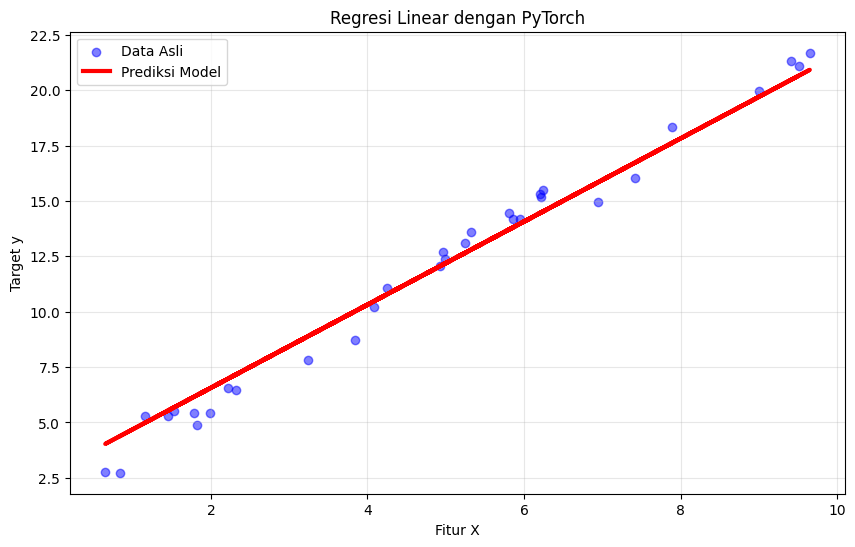

In [ ]:
import matplotlib.pyplot as plt

model.eval()

# Ambil satu batch data validasi
x_val_batch, y_val_batch = next(iter(val_loader))

# Pindahkan ke device yang sama dengan model untuk prediksi
x_val_device = x_val_batch.to(device)

with torch.no_grad():
    y_pred = model(x_val_device)

# Pindahkan kembali ke CPU untuk plotting
x_val_plot = x_val_batch.cpu().numpy()
y_val_plot = y_val_batch.cpu().numpy()
y_pred_plot = y_pred.cpu().numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x_val_plot, y_val_plot, label='Data Asli', color='blue', alpha=0.5)
plt.plot(x_val_plot, y_pred_plot, label='Prediksi Model', color='red', linewidth=3)
plt.title('Regresi Linear dengan PyTorch')
plt.xlabel('Fitur X')
plt.ylabel('Target y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

model.eval()

# Get one batch of validation data
x_val_batch, y_val_batch = next(iter(val_loader))

# Move to the same device as the model for prediction
x_val_device = x_val_batch.to(device)

with torch.no_grad():
    y_pred = model(x_val_device)

# Move back to CPU for plotting
x_val_plot = x_val_batch.cpu().numpy()
y_val_plot = y_val_batch.cpu().numpy()
y_pred_plot = y_pred.cpu().numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x_val_plot, y_val_plot, label='Original Data', color='blue', alpha=0.5)
plt.plot(x_val_plot, y_pred_plot, label='Model Prediction', color='red', linewidth=3)
plt.title('Linear Regression with PyTorch')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. Versi PyTorch Lightning

In [ ]:
class SimpleRegressionLightning(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(1,1)

        self.criterion = nn.MSELoss()

        self.save_hyperparameters()

    def forward(self, x):
        return self.layer(x)

    def training_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self(X) # Corrected: use X (uppercase)
        loss = self.criterion(y_hat, y)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch # Corrected: unpack batch, not batch_idx
        y_hat = self(X) # Corrected: use X (uppercase)
        loss = self.criterion(y_hat, y) # Corrected: use lowercase 'loss'

        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=0.01)

Training model

In [ ]:
model = SimpleRegressionLightning()

trainer = pl.Trainer(max_epochs=50, accelerator="auto", devices=1)

print("Memulai proses training...")
# TODO
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print("Training selesai!")


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Memulai proses training...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer     │ Linear  │      2 │ train │     0 │
│ 1 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 2                                                                                                
Non-trainable params: 0                                                                                            
Total params: 2                                                                                                    
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Training selesai!


Visualisasi

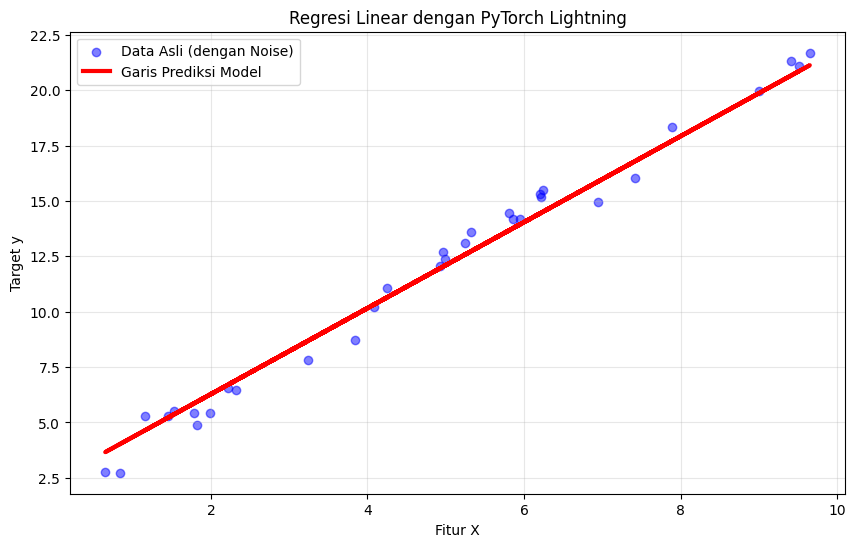

In [ ]:
import matplotlib.pyplot as plt

model.eval()

x_val_batch, y_val_batch = next(iter(val_loader))

with torch.no_grad():
    y_pred = model(x_val_batch)

plt.figure(figsize=(10, 6))

# Plot data asli (scatter plot)
plt.scatter(x_val_batch.numpy(), y_val_batch.numpy(), label='Data Asli (dengan Noise)', color='blue', alpha=0.5)

# Plot prediksi model (garis merah)
plt.plot(x_val_batch.numpy(), y_pred.numpy(), label='Garis Prediksi Model', color='red', linewidth=3)

plt.title('Regresi Linear dengan PyTorch Lightning')
plt.xlabel('Fitur X')
plt.ylabel('Target y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
